<a href="https://colab.research.google.com/github/raissabarb/cn/blob/main/Atividade_2_Raissa_Barbosa_e_Isabela_Completo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Atividade 2


*   Isabela (Exercícios 6 e 7 + revisão)
*   Raissa Barbosa (Exercícios 1, 2, 3, 4 e 5 + revisão)



In [8]:
import numpy as np
import matplotlib.pyplot as plt

# **1. Verificação da estabilidade.**

In [9]:
def calcularDeltaY(h, nPontos):
  deltaY = (h / (nPontos - 1))
  print('Δy = ', deltaY)
  return deltaY


def calcularDeltaTmax(deltaY, v):
  deltaTmax = (deltaY**2 / (2 * v))
  print('ΔTmax = ', deltaTmax)
  return deltaTmax


def calcularR(v, deltaT, deltaY):
  r = (v * deltaT) / ((deltaY)**2)
  print('r = ', r)
  return r


h = 0.01
nPontos = 21
v = 10**(-4)

deltaY = calcularDeltaY (h, nPontos)
deltaTmax = calcularDeltaTmax(deltaY, v)

# caso A
deltaT_A = 0.001
calcularR(v, deltaT_A, deltaY)

# caso B
deltaT_B = 0.002
calcularR(v, deltaT_B, deltaY)

Δy =  0.0005
ΔTmax =  0.0012499999999999998
r =  0.4000000000000001
r =  0.8000000000000002


0.8000000000000002

Para o caso A, temos que é estável. Já para o caso B, instável.

# **2. Detecção de overflow.**

In [10]:
def simular(dt, tipo=np.float32, passos=2000, pontos=21):
    """Simula difusao de velocidade e detecta falhas."""

    H = 0.01
    nu = 1e-4

    y = np.linspace(0, H, pontos)
    dy = H / (pontos - 1)

    # Coeficientes no tipo numerico escolhido.
    r = tipo(nu * dt / dy**2)
    dois = tipo(2)

    # Fluido parado e placa em y=0 em movimento.
    u = np.zeros(pontos, dtype=tipo)
    u[0] = tipo(1)

    tempos = [0.0]
    maximos = [float(np.max(np.abs(u)))]
    falha = None

    # Transforma avisos numericos em excecoes.
    with np.errstate(over="raise", invalid="raise"):
        for passo in range(1, passos + 1):
            try:
                novo = u.copy()

                # Atualiza o interior e preserva as paredes.
                novo[1:-1] = (
                    u[1:-1]
                    + r * (
                        u[2:] - dois * u[1:-1] + u[:-2]
                    )
                )

            except FloatingPointError as erro:
                falha = passo
                print(
                    f"dt={dt}, {tipo.__name__}: "
                    f"falha no passo {passo}, "
                    f"t={passo * dt:.4f} s - {erro}"
                )
                break

            u = novo
            tempos.append(passo * dt)
            maximos.append(float(np.max(np.abs(u))))

    if falha is None:
        print(f"Δt={dt}, {tipo.__name__}: " f"{passos} passos sem overflow.")

    return {
        "y": y,
        "u": u,
        "tempos": tempos,
        "maximos": maximos,
        "r": float(r),
        "falha": falha,
    }


def rodarTestes(tiposNumericos, deltas):
    resultados = {}
    tabela = []

    for tipo in tiposNumericos:
        for deltaT in deltas:
            nome = f'{tipo.__name__}, deltaT={deltaT}'
            resultado = simular(deltaT, tipo)
            resultados[nome] = resultado

            overflow = resultado['falha'] is not None
            tabela.append({
                'tipo_numerico': tipo.__name__,
                'Δt': deltaT,
                'r': resultado['r'],
                'overflow': overflow,
                'passo_falha': resultado['falha'] if overflow else '-',
            })

    return resultados, tabela


def imprimirTabela(tabela):
    print(f"{'Tipo num':<10} {'Δt':<8} {'r':<8} {'Overflow':<10} {'Passo da falha'}")
    print('-------------------------------------------------------')

    for linha in tabela:
        print(f"{linha['tipo_numerico']:<10} {linha['Δt']:<8} {linha['r']:<8.2f} " f"{str(linha['overflow']):<10} {linha['passo_falha']}")


tipos = (np.float32, np.float64)
deltas = (0.001, 0.002)

resultados, tabela = rodarTestes(tipos, deltas)
print('\n')
imprimirTabela(tabela)

Δt=0.001, float32: 2000 passos sem overflow.
dt=0.002, float32: falha no passo 121, t=0.2420 s - overflow encountered in subtract
Δt=0.001, float64: 2000 passos sem overflow.
dt=0.002, float64: falha no passo 917, t=1.8340 s - overflow encountered in add


Tipo num   Δt       r        Overflow   Passo da falha
-------------------------------------------------------
float32    0.001    0.40     False      -
float32    0.002    0.80     True       121
float64    0.001    0.40     False      -
float64    0.002    0.80     True       917


# **3. Interpretação física.**

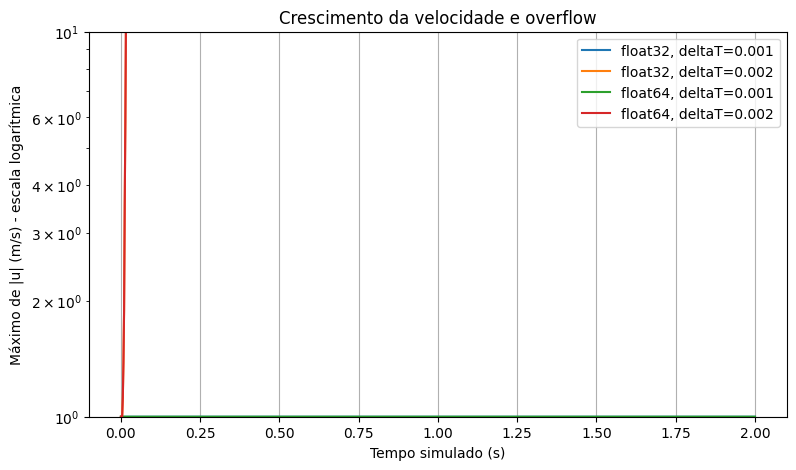

In [11]:
plt.figure(figsize=(9, 5))
for nome, resultado in resultados.items():
    plt.semilogy(
        resultado["tempos"],
        resultado["maximos"],
        label=nome
    )

plt.xlabel("Tempo simulado (s)")
plt.ylabel("Máximo de |u| (m/s) - escala logarítmica")
plt.title("Crescimento da velocidade e overflow")
plt.grid(True)
plt.legend()
plt.show()

No gráfico, as curvas de r=0,4 ficam praticamente retas em torno de 1 m/s do início ao fim — ou seja, a velocidade para de crescer. Já as curvas de r=0,8 disparam rapidamente para valores absurdos (muito acima de 1 m/s) e continuam subindo até o programa parar por overflow. Isso não é físico porque, no problema, nada pode fazer o fluido andar mais rápido que a própria placa que o está empurrando (que anda a 1 m/s). Então, quando a velocidade calculada passa muito de 1 m/s, já sabemos que o resultado está errado, pois o crescimento vem de um erro do método numérico usado (r>0,5), não de um efeito real do fluido.

# **4. Capacidade de representação.**

Não, não elimina a instabilidade. Nos dois casos, de float32 e float64, com Δt=0,002 (r=0,8), a velocidade cresce e o programa acaba falhando. A diferença entre os dois tipos é o momento em que o overflow ocorre, pois o float32 estoura com 121 passos e o float64 com 917, pois tem uma capacidade de representar números maiores.

# **5. Refinamento da malha.**

In [12]:
h = 0.01
nPontos = 41
v = 10**(-4)
deltaT_antigo = 0.001

deltaY_41 = calcularDeltaY(h, nPontos)
deltaTmax_41 = calcularDeltaTmax(deltaY_41, v)
r_41_antigo = calcularR(v, deltaT_antigo, deltaY_41)

# simulação 1
print('\n*** Resultado Simulação com 41 pontos ***\n')
resultado_41 = simular(deltaT_antigo, np.float64, passos=2000, pontos=nPontos)
print("Falha no passo:", resultado_41["falha"])

Δy =  0.00025
ΔTmax =  0.00031249999999999995
r =  1.6000000000000003

*** Resultado Simulação com 41 pontos ***

dt=0.001, float64: falha no passo 426, t=0.4260 s - overflow encountered in subtract
Falha no passo: 426


In [13]:
deltaT_novo = 0.0003
r_41_novo = calcularR(v, deltaT_novo, deltaY_41)

# simulação 2
print('\n*** Resultado Simulação com 41 pontos ***\n')
resultado_41_estavel = simular(deltaT_novo, np.float64, passos=2000, pontos=41)
print("Falha no passo:", resultado_41_estavel["falha"])

r =  0.48

*** Resultado Simulação com 41 pontos ***

Δt=0.0003, float64: 2000 passos sem overflow.
Falha no passo: None


Ao usar uma malha mais fina com 41 pontos, o espaço entre os pontos ficou menor, e isso reduziu o valor máximo de Δt, que é o permitido para manter a simulação estável. Por isso, o Δt=0,001 s, que funcionava bem antes, passou a causar instabilidade e overflow. Diminuindo o Δt para 0,0003s, o valor de r ficou abaixo de 0,5 novamente, e a simulação voltou a rodar de forma estável, sem overflow.

##6. Verificação do perfil de velocidade.

r = 0.4000000000000001
tempo caracteristico (H^2/nu) = 1.0 s
numero de passos = 5000  -> t_total = 5.0 s

Maior diferenca entre numerico e estacionario (E_inf): 3.4416913763379853e-15


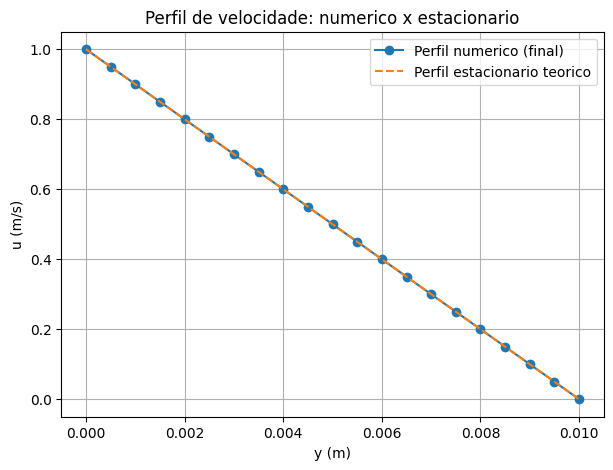

In [14]:
# ---------- 1. Dados do problema ----------
H = 0.01
nu = 1e-4
U = 1.0

n_pontos = 21
dy = H / (n_pontos - 1)
dt = 0.001                 # (Caso A foi escolhido)

r = nu * dt / dy**2
print("r =", r)

# ---------- 2. Tempo total de simulacao ----------
tau = H**2 / nu
print("tempo caracteristico (H^2/nu) =", tau, "s")

t_total = 5 * tau              # 5x o tempo de difusao
n_passos = int(t_total / dt)
print("numero de passos =", n_passos, " -> t_total =", n_passos * dt, "s")

# ---------- 3. Malha de posicoes e condicao inicial ----------
y = np.linspace(0, H, n_pontos)

u = np.zeros(n_pontos)
u[0] = U
u[-1] = 0.0

# ---------- 4. Laco no tempo  ----------
for passo in range(n_passos):
    u_novo = u.copy()

    for i in range(1, n_pontos - 1):
        u_novo[i] = u[i] + r * (u[i+1] - 2*u[i] + u[i-1])

    u = u_novo

# ---------- 5. Solucao estacionaria teorica passada no ex ----------
u_estacionario = U * (1 - y / H)

# ---------- 6. Comparando as duas ----------
diferenca = np.abs(u - u_estacionario)
E_inf = np.max(diferenca)

print("\nMaior diferenca entre numerico e estacionario (E_inf):", E_inf)

# ---------- 7. Grafico ----------
plt.figure(figsize=(7, 5))
plt.plot(y, u, 'o-', label="Perfil numerico (final)")
plt.plot(y, u_estacionario, '--', label="Perfil estacionario teorico")
plt.xlabel("y (m)")
plt.ylabel("u (m/s)")
plt.title("Perfil de velocidade: numerico x estacionario")
plt.legend()
plt.grid(True)
plt.show()

*"Discuta se o tempo simulado foi suficiente para aproximar o regime estacionário."*: Sim, foi suficiente. Foi escolhida uma configuração estável (caso A) e como o tempo de difusão é 1 segundo, a simulação usou um tempo de 5 segundos, suficiente para se aproximar do perfil estacionário. A diferença máxima em relação ao perfil estacionário ficou na casa dos 10^-15, uma diferença bem pequena.


##7. Conclusão.

*"Explique a relação entre refinamento da malha, passo de tempo, instabilidade numérica e
overflow. Indique qual alteração corrigiu a causa da falha nesta simulação."*

Apenas fazer um refinamento da malha não é algo que garante uma simulação mais precisa. Quando isso é feito, também é necessário reduzir delta t proporcionalmente para que a solução continue sendo estável. Caso isso não ocorra, uma malha mais fina pode transformar uma solução estável em uma instável.

Mais especificamente, a estabilidade depende do r, que combina 3 grandezas: a viscosidade, o refinamento da malha e o passo de tempo (não depende de tipo numérico, o tipo numérico só influencia quando e se o overflow ocorrerá). Ela que decide se a simulação vai funcionar ou vai explodir (r precisa ser <= 1/2 para que a solução seja estável).

Por sua vez, a instabilidade faz o valor máximo crescer sem controle até estourar o tipo numérico, causando um overflow. Ou seja, o overflow ocorre depois da instabilidade: uma solução pode estar instável muito antes do overflow acontecer.

O que corrigiu a causa da falha foi reduzir delta t até satisfazer r <= 1/2. A mudança de tipo numérico pode adiar a falha, mas não a resolve.
